In [33]:
import sys
print(sys.path)

sys.path.insert(1, '/home/andreas/prj_AH/analysis_buckle') ## this is the path to the pybuckle package.
                                                            ## only necessary if the location is not in your
                                                            ## python path


import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt

import h5py
        
import astropy.units as units           # astropy is only used for conveniently convert units, 
from astropy.constants import k_B, N_A  # not strictly necessary
import MDAnalysis as mda

from scipy.integrate import cumtrapz

from pybuckle.fourier import *
from pybuckle.solveBVP import BuckleBVPSolver, makeTables
from pybuckle.getshapecoeff import BucklesShapeFCoeff
from pybuckle.fitshape import FitShape, prefit_fun
from pybuckle.misc import calc_curvature, calc_dKds, min_image_dist, rotateVec


SMALL_SIZE = 16
MEDIUM_SIZE = 20 
BIGGER_SIZE = 24

plt.rc('axes', labelsize=MEDIUM_SIZE)
plt.rc('axes', titlesize=SMALL_SIZE)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)

['/home/andreas/prj_AH/buckle_hecate_x', '/home/andreas/prj_AH/analysis_buckle', '/usr/lib/python38.zip', '/usr/lib/python3.8', '/usr/lib/python3.8/lib-dynload', '', '/home/andreas/.local/lib/python3.8/site-packages', '/usr/local/lib/python3.8/dist-packages', '/usr/local/lib/python3.8/dist-packages/memsurfer-1.1.0-py3.8-linux-x86_64.egg', '/usr/local/lib/python3.8/dist-packages/vtk-9.2.0rc2-py3.8-linux-x86_64.egg', '/usr/local/lib/python3.8/dist-packages/numpy-1.23.2-py3.8-linux-x86_64.egg', '/usr/local/lib/python3.8/dist-packages/wslink-1.7.0-py3.8.egg', '/usr/local/lib/python3.8/dist-packages/matplotlib-3.5.3-py3.8-linux-x86_64.egg', '/usr/local/lib/python3.8/dist-packages/aiohttp-3.8.1-py3.8-linux-x86_64.egg', '/usr/local/lib/python3.8/dist-packages/kiwisolver-1.4.4-py3.8-linux-x86_64.egg', '/usr/local/lib/python3.8/dist-packages/fonttools-4.35.0-py3.8.egg', '/usr/local/lib/python3.8/dist-packages/cycler-0.11.0-py3.8.egg', '/usr/local/lib/python3.8/dist-packages/yarl-1.8.1-py3.8-lin

In [34]:
plt.rcParams['figure.figsize'] = 14, 14 #/ aspect_ratio
plt.rcParams['legend.fontsize'] = SMALL_SIZE

In [35]:
%load_ext autoreload
#%load_ext line_profiler

%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
#basedir = '/large/stroh1/curve_sens/tutorial/'
basedir = '/home/andreas/prj_AH/buckle_hecate_x/'
#workdir = basedir + 'sampling/pull/'
workdir = basedir
umbdir = workdir + 'UMBRELLA/'

frame_info = pd.read_csv(umbdir + 'caught-output.dat', header=0, delim_whitespace=True)

#membraneOnly_box_x = np.loadtxt(basedir + 'membraneOnly/NPT/box-x.xvg', skiprows=24)

u = mda.Universe(workdir + 'pull.tpr', workdir + 'pull_reduced.xtc')

lx = u.dimensions[0] / 10
ly = u.dimensions[1] / 10
lz = u.dimensions[2] / 10
print(lx, ly, lz)

#L0 = np.mean(membraneOnly_box_x[:,1])
L0 = 30
print('L0 = %f' %L0)
Lx = lx
g = Lx / L0
print(g)


21.0 10.0 22.20881042480469
L0 = 30.000000
0.7


Conversion of the force constant from gromacs units to kT

In [37]:
k_gromacs = 100
T = 310
k_gromacs_units = k_gromacs * units.kJ / units.mol / units.nm**2
k_kbT = k_gromacs_units / (k_B * T * units.K * N_A).to('kJ/mol')

k = k_kbT.value
k

38.79753388475033

Load shape data

In [38]:
hf = h5py.File(umbdir + 'shape_data.h5', 'r')

In [39]:
list(hf.keys())

['minim_g_out_all', 'shape_coeff']

In [40]:
x0_mean = np.mean(hf['minim_g_out_all'][:,0])
x0_std  = np.std(hf['minim_g_out_all'][:,0])

z0_mean = np.mean(hf['minim_g_out_all'][:,1])
z0_std  = np.std(hf['minim_g_out_all'][:,1])

g_mean = np.mean(hf['minim_g_out_all'][:,2])
g_std  = np.std(hf['minim_g_out_all'][:,2])

print(x0_mean, x0_std, x0_std / x0_mean)
print(z0_mean, z0_std, z0_std / z0_mean)
print(g_mean,  g_std,  g_std  / g_mean)

6.324593441832892 0.03584137143971802 0.005666984252719184
6.06268273841992 0.033676529948788045 0.005554724105118678
0.7293539059803824 0.0024897769079824713 0.003413674606480327


In [41]:
L_hat = lx / g_mean
L_hat

28.792606480625114

In [42]:
s_plot = hf['shape_coeff/s_plot'][:].reshape(-1)
print(s_plot)

[-0.3223632 -0.3222632 -0.3221632 ...  0.6774368  0.6775368  0.6776368]


In [43]:
s01 = np.linspace(0, 1, int(1e6)+1)
outsideshaper = BucklesShapeFCoeff()
fitted_shape_coeff = outsideshaper.get_FCoeff(g_mean, Lx, s=s01)

ax_at_fitted_g = fitted_shape_coeff[12]
az_at_fitted_g = fitted_shape_coeff[13]
X = fitted_shape_coeff[0]
Z = fitted_shape_coeff[1]

curv = calc_curvature(fitted_shape_coeff)
dKds = calc_dKds(fitted_shape_coeff)

# dXdg = fitted_shape_coeff[2]
# dZdg = fitted_shape_coeff[3]
dXds = fitted_shape_coeff[4]
dZds = fitted_shape_coeff[5]
# d2Xdg2 = fitted_shape_coeff[6]
# d2Zdg2 = fitted_shape_coeff[7]
# d2Xds2 = fitted_shape_coeff[8]
# d2Zds2 = fitted_shape_coeff[9]
# d2Xdsdg = fitted_shape_coeff[10]
# d2Zdsdg = fitted_shape_coeff[11]

# d3Xds3 = fitted_shape_coeff[14]
# d3Zds3 = fitted_shape_coeff[15]

In [44]:
absdrds = np.sqrt((dXds / L_hat)**2 + (dZds / L_hat)**2)
absdrds

array([1.00000016, 1.00000016, 1.00000016, ..., 1.00000016, 1.00000016,
       1.00000016])

Calculate offset curve. In this case the offset used was 2 nm. 

In [45]:
d = 2.0

s_middle = np.zeros_like(s01)
s_offset = np.zeros_like(s01)

s_middle[1:] = cumtrapz(absdrds, dx=(s01[1:] - s01[:-1]))
s_offset[1:] = cumtrapz(np.abs(1 + curv * d), dx=(s01[1:] - s01[:-1]))

L_middle = L_hat * s01
L_offset = L_hat * s_offset

In [46]:
nWin = frame_info.shape[0]
print(nWin)
#s_window = np.linspace(0.25, 0.5, nWin) # enter the used s range here
s_window = np.linspace(0.0, 0.5, nWin) # enter the used s range here
s_win_flip = np.flip(s_window)
s_window, s_win_flip

64


(array([0.        , 0.00793651, 0.01587302, 0.02380952, 0.03174603,
        0.03968254, 0.04761905, 0.05555556, 0.06349206, 0.07142857,
        0.07936508, 0.08730159, 0.0952381 , 0.1031746 , 0.11111111,
        0.11904762, 0.12698413, 0.13492063, 0.14285714, 0.15079365,
        0.15873016, 0.16666667, 0.17460317, 0.18253968, 0.19047619,
        0.1984127 , 0.20634921, 0.21428571, 0.22222222, 0.23015873,
        0.23809524, 0.24603175, 0.25396825, 0.26190476, 0.26984127,
        0.27777778, 0.28571429, 0.29365079, 0.3015873 , 0.30952381,
        0.31746032, 0.32539683, 0.33333333, 0.34126984, 0.34920635,
        0.35714286, 0.36507937, 0.37301587, 0.38095238, 0.38888889,
        0.3968254 , 0.4047619 , 0.41269841, 0.42063492, 0.42857143,
        0.43650794, 0.44444444, 0.45238095, 0.46031746, 0.46825397,
        0.47619048, 0.48412698, 0.49206349, 0.5       ]),
 array([0.5       , 0.49206349, 0.48412698, 0.47619048, 0.46825397,
        0.46031746, 0.45238095, 0.44444444, 0.43650794, 0.

In [47]:
sWin_ndx = np.argmin(np.abs(s_win_flip.reshape(-1,1) - s01), axis=1)
sWin_ndx

array([500000, 492063, 484127, 476190, 468254, 460317, 452381, 444444,
       436508, 428571, 420635, 412698, 404762, 396825, 388889, 380952,
       373016, 365079, 357143, 349206, 341270, 333333, 325397, 317460,
       309524, 301587, 293651, 285714, 277778, 269841, 261905, 253968,
       246032, 238095, 230159, 222222, 214286, 206349, 198413, 190476,
       182540, 174603, 166667, 158730, 150794, 142857, 134921, 126984,
       119048, 111111, 103175,  95238,  87302,  79365,  71429,  63492,
        55556,  47619,  39683,  31746,  23810,  15873,   7937,      0])

In [48]:
xi_ref_middle = L_middle[sWin_ndx]
xi_ref_middle

array([14.39630324, 14.16777632, 13.9392782 , 13.71075128, 13.48225315,
       13.25372624, 13.02522811, 12.79670119, 12.56820307, 12.33967615,
       12.11117803, 11.88265111, 11.65415298, 11.42562607, 11.19712794,
       10.96860102, 10.7401029 , 10.51157598, 10.28307786, 10.05455094,
        9.82605281,  9.5975259 ,  9.36902777,  9.14050085,  8.91200273,
        8.68347581,  8.45497769,  8.22645077,  7.99795264,  7.76942573,
        7.5409276 ,  7.31240068,  7.08390256,  6.85537564,  6.62687751,
        6.3983506 ,  6.16985247,  5.94132555,  5.71282743,  5.48430051,
        5.25580239,  5.02727547,  4.79877734,  4.57025043,  4.3417523 ,
        4.11322538,  3.88472726,  3.65620034,  3.42770222,  3.1991753 ,
        2.97067717,  2.74215026,  2.51365213,  2.28512521,  2.05662709,
        1.82810017,  1.59960205,  1.37107513,  1.142577  ,  0.91405009,
        0.68555196,  0.45702504,  0.22852692,  0.        ])

In [49]:
xi_ref_offset = L_offset[sWin_ndx]
xi_ref_offset

array([14.39630324, 14.05811926, 13.72029379, 13.38305577, 13.04680057,
       12.71174844, 12.3782817 , 12.04660567, 11.71708326, 11.38989968,
       11.06539342, 10.74372579, 10.42520731, 10.10997315,  9.79830384,
        9.49030761,  9.18623445,  8.88616604,  8.59032252,  8.29876053,
        8.01167188,  7.7290903 ,  7.45118142,  7.17795855,  6.90956344,
        6.64599151,  6.38736298,  6.13365772,  5.88497643,  5.64128537,
        5.40266734,  5.16907632,  4.94057819,  4.71711538,  4.49873716,
        4.28537439,  4.07705943,  3.87371085,  3.67534313,  3.48186122,
        3.29326008,  3.10942912,  2.93034175,  2.75586949,  2.58596189,
        2.42047005,  2.25931732,  2.10233189,  1.9494088 ,  1.8003512 ,
        1.65502425,  1.51320458,  1.37472681,  1.23934061,  1.10685062,
        0.97698036,  0.84950652,  0.72412872,  0.60059921,  0.4785975 ,
        0.35785645,  0.23804063,  0.11886985,  0.        ])

Read in pull data directly from gromacs output files. The number of rows to skip might need to be adapted to your output.

In [50]:
pullx0 = pd.read_csv(umbdir + 'umbrella%d_pullx.xvg' %frame_info['frame'].iloc[0],
                        names=['t', 'dxi'],
                        skiprows=25,
                        usecols=[0,1],
                        delim_whitespace=True).to_numpy()

pullx = np.zeros((pullx0.shape[0], nWin+1))

pullx[:,0:2] = pullx0
nDataPoints = np.zeros(pullx.shape[1] - 1)
nDataPoints[0] = pullx0.shape[0]

for i, frame in enumerate(frame_info['frame'].iloc[1:]):
    print(i+2, frame)
    temp_data = (pd.read_csv(umbdir + 'umbrella%d_pullx.xvg' %frame, 
                                usecols=[1], 
                                names=['dxi'], 
                                skiprows=25, 
                                delim_whitespace=True).to_numpy()).reshape(-1)
    print(temp_data.shape)
    nDataPoints[i+1] = temp_data.shape[0]
    pullx[:int(nDataPoints[i+1]), i+2] = temp_data
    


2 40
(599993,)
3 42
(599993,)
4 63
(599993,)
5 69
(599993,)
6 80
(599993,)
7 94
(599993,)
8 100
(599993,)
9 117
(599993,)
10 121
(599993,)
11 138
(599993,)
12 145
(599993,)
13 148
(599993,)
14 154
(599993,)
15 162
(599993,)
16 178
(599993,)
17 181
(599993,)
18 186
(599993,)
19 197
(599993,)
20 204
(599993,)
21 206
(599993,)
22 212
(599993,)
23 221
(599993,)
24 224
(599993,)
25 226
(599993,)
26 229
(599993,)
27 240
(599993,)
28 243
(599993,)
29 246
(599993,)
30 248
(599993,)
31 251
(599993,)
32 261
(599993,)
33 266
(599993,)
34 269
(599993,)
35 271
(599993,)
36 272
(599993,)
37 276
(599993,)
38 288
(599993,)
39 289
(599993,)
40 291
(599993,)
41 294
(599993,)
42 301
(599993,)
43 302
(599993,)
44 303
(599993,)
45 308
(599993,)
46 312
(599993,)
47 317
(599993,)
48 320
(599993,)
49 321
(599993,)
50 322
(599993,)
51 323
(599993,)
52 326
(599993,)
53 327
(599993,)
54 339
(599993,)
55 340
(599993,)
56 349
(599993,)
57 354
(599993,)
58 356
(599993,)
59 357
(599993,)
60 366
(599993,)
61 370
(599

In [51]:
nBins = 2000

xi_bins = np.linspace(xi_ref_offset[-1], L_hat / 2, nBins+1)
xi_bins

array([0.00000000e+00, 7.19815162e-03, 1.43963032e-02, ...,
       1.43819069e+01, 1.43891051e+01, 1.43963032e+01])

In [52]:
xi_bins_center = xi_bins[:-1] + (xi_bins[1] - xi_bins[0]) / 2
xi_bins_center

array([3.59907581e-03, 1.07972274e-02, 1.79953791e-02, ...,
       1.43783079e+01, 1.43855060e+01, 1.43927042e+01])

In [53]:
#xi = pullx[50000:].copy() # first 50 ns for equilibration are not included in the analysis
xi = pullx[10000:].copy() # first 2 ns  
xi[:,1:] += xi_ref_offset.reshape(1, nWin)

In this tutorial, I simply calculate the mean and the variance. Normally, you want to decorrelate the data and do some statistical tests, as described in the paper in section 2.2. This is also necessary for estimating the statistical error.

In [54]:
xi_mean = np.zeros(nDataPoints.shape[0])
xi_var = np.zeros(nDataPoints.shape[0])

for i in range(nDataPoints.shape[0]):
    xi_mean[i] = np.mean(xi[:int(nDataPoints[i]),i+1], axis=0) 
    xi_var[i] = np.var(xi[:int(nDataPoints[i]),i+1], axis=0, ddof=1)

In [55]:
xi_mean, xi_var, np.sqrt(xi_var)

(array([14.38735514, 14.05930233, 13.72986315, 13.36756474, 13.04682906,
        12.71209835, 12.38157646, 12.05278066, 11.70638745, 11.38182517,
        11.07146703, 10.73646513, 10.44811993, 10.09701461,  9.80014734,
         9.49908734,  9.20846064,  8.89680113,  8.58833756,  8.29729111,
         8.01883235,  7.72388368,  7.45119441,  7.18553034,  6.91610291,
         6.6526628 ,  6.41227728,  6.14286032,  5.89135119,  5.66354292,
         5.41307539,  5.17829159,  4.94961799,  4.73812735,  4.50772033,
         4.30304881,  4.10307723,  3.88464557,  3.71036095,  3.49983197,
         3.33021933,  3.13772349,  2.95221477,  2.78215897,  2.57758126,
         2.41521154,  2.25008418,  2.10885153,  1.9595992 ,  1.78111407,
         1.6419629 ,  1.50842448,  1.3915748 ,  1.23655877,  1.12829452,
         1.00697005,  0.86202519,  0.70639804,  0.60669586,  0.50063063,
         0.32949838,  0.23695608,  0.10593903, -0.02399114]),
 array([0.02536655, 0.02491954, 0.02688937, 0.02498822, 0.0243

In [56]:
xi

array([[ 1.50120000e+04,  1.42654212e+01,  1.39998335e+01, ...,
         4.24448631e-01,  2.26663854e-01,  6.43864000e-02],
       [ 1.50135000e+04,  1.42711622e+01,  1.39837223e+01, ...,
         3.93038631e-01,  2.42258854e-01,  7.03085000e-02],
       [ 1.50150000e+04,  1.42822202e+01,  1.39951504e+01, ...,
         3.65632631e-01,  2.04774454e-01,  4.24655000e-02],
       ...,
       [ 8.99997000e+05,  1.42537722e+01,  1.36944743e+01, ...,
         1.98109431e-01,  5.37266539e-02, -1.98850000e-01],
       [ 8.99998500e+05,  1.42442982e+01,  1.36947143e+01, ...,
         1.60176031e-01,  3.06580539e-02, -2.00419000e-01],
       [ 9.00000000e+05,  1.42271902e+01,  1.36594573e+01, ...,
         1.28364631e-01,  5.20787539e-02, -1.91884000e-01]])

In [57]:
dAi_udx =( (xi_bins_center.reshape(-1,1) - xi_mean.reshape(1,-1)) 
            / xi_var - k * (xi_bins_center.reshape(-1,1) - xi_ref_offset.reshape(1,-1)) )
dAi_udx

array([[-8.63495801e+00, -1.87626231e+01,  2.17022506e+01, ...,
         4.75129946e-03,  2.34876993e-01,  9.34725706e-01],
       [-8.63046304e+00, -1.87530380e+01,  2.16906751e+01, ...,
         5.90268308e-03,  2.53643067e-01,  9.35750647e-01],
       [-8.62596806e+00, -1.87434528e+01,  2.16790995e+01, ...,
         7.05406669e-03,  2.72409141e-01,  9.36775588e-01],
       ...,
       [ 3.41514344e-01,  3.78891023e-01, -1.41404659e+00, ...,
         2.30406437e+00,  3.77107273e+01,  2.98153298e+00],
       [ 3.46009322e-01,  3.88476157e-01, -1.42562210e+00, ...,
         2.30521575e+00,  3.77294934e+01,  2.98255792e+00],
       [ 3.50504301e-01,  3.98061292e-01, -1.43719761e+00, ...,
         2.30636714e+00,  3.77482595e+01,  2.98358286e+00]])

In [58]:
Pi_b = 1 / np.sqrt(xi_var * 2 * np.pi) * np.exp(-0.5 * (xi_bins_center.reshape(-1,1) - xi_mean.reshape(1,-1))**2 / xi_var) 
Pi_b.shape

(2000, 64)

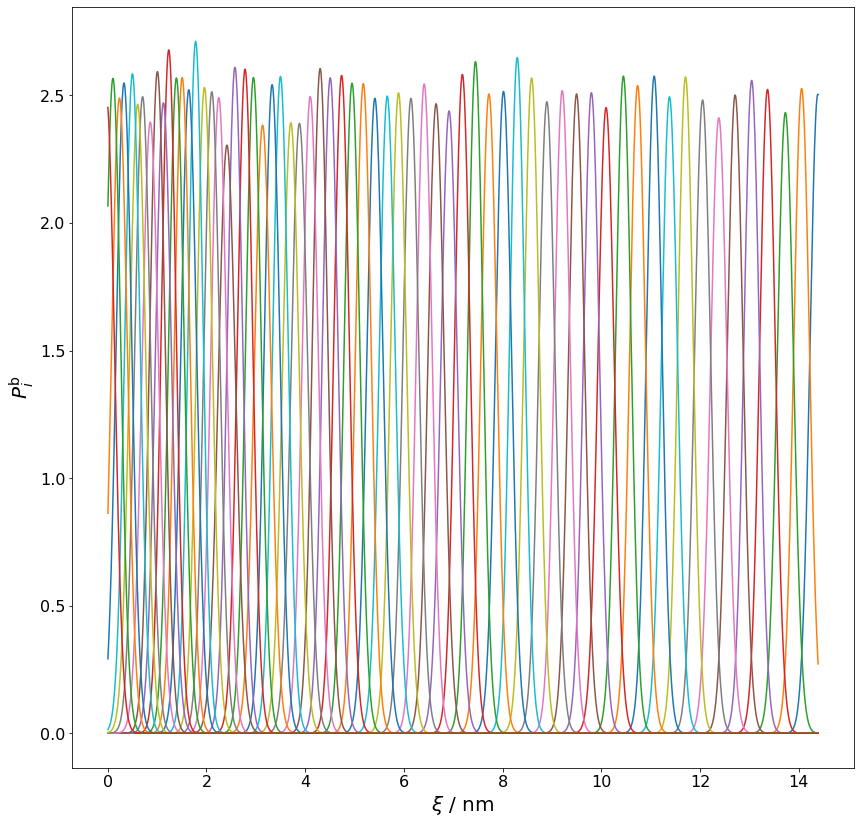

In [59]:
plt.plot(xi_bins_center, Pi_b[:,0::1])

plt.xlabel(r'$\xi$ / nm')
plt.ylabel('$P_{i}^{\mathrm{b}}$')
plt.show()

In [60]:
pi_nDataPoints = nDataPoints * Pi_b / np.sum(nDataPoints * Pi_b, axis=1).reshape(-1,1)

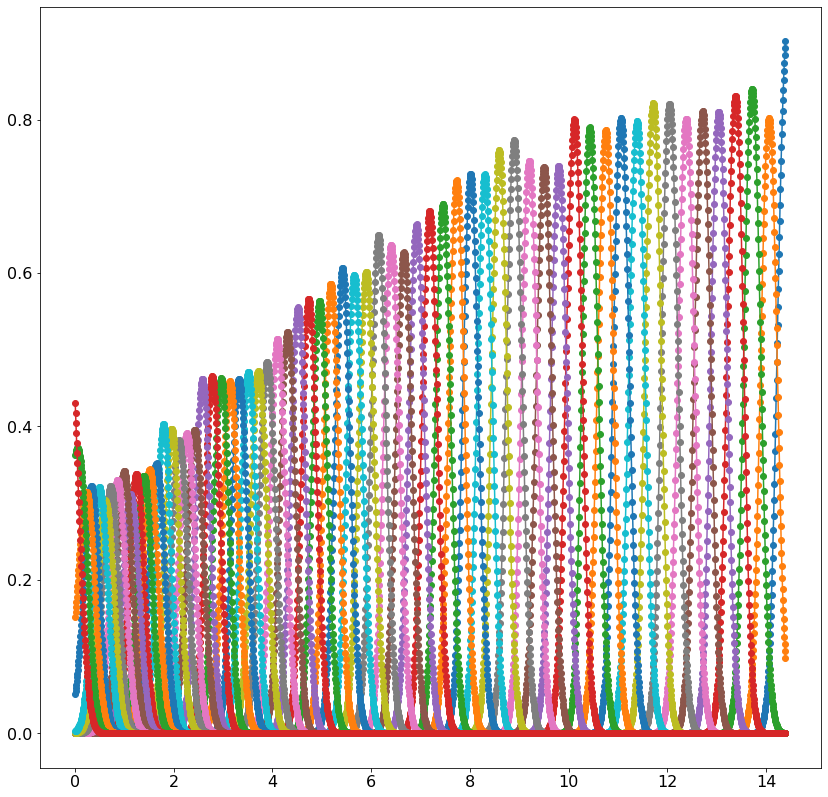

In [61]:
plt.plot(xi_bins_center, pi_nDataPoints[:,0::1], 'o-')
plt.show()

In [64]:
dA_udx = np.sum(pi_nDataPoints * dAi_udx, axis=1 )


In [65]:
pmf_xi = np.cumsum(dA_udx * (xi_bins[1] - xi_bins[0]) ) 

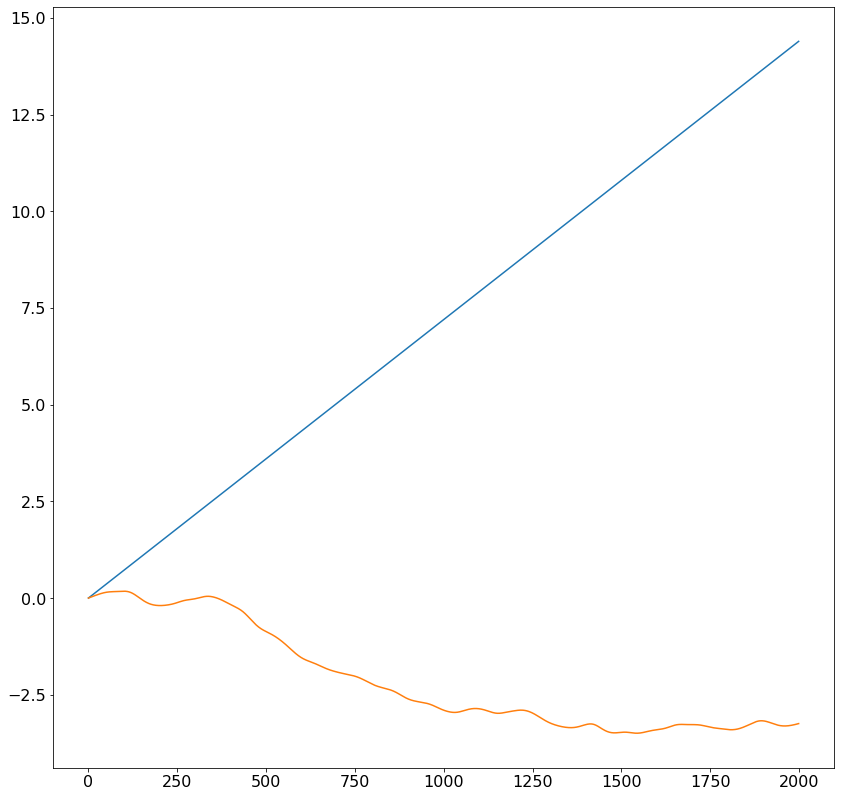

In [66]:
plt.plot(xi_bins_center )
plt.plot(pmf_xi)

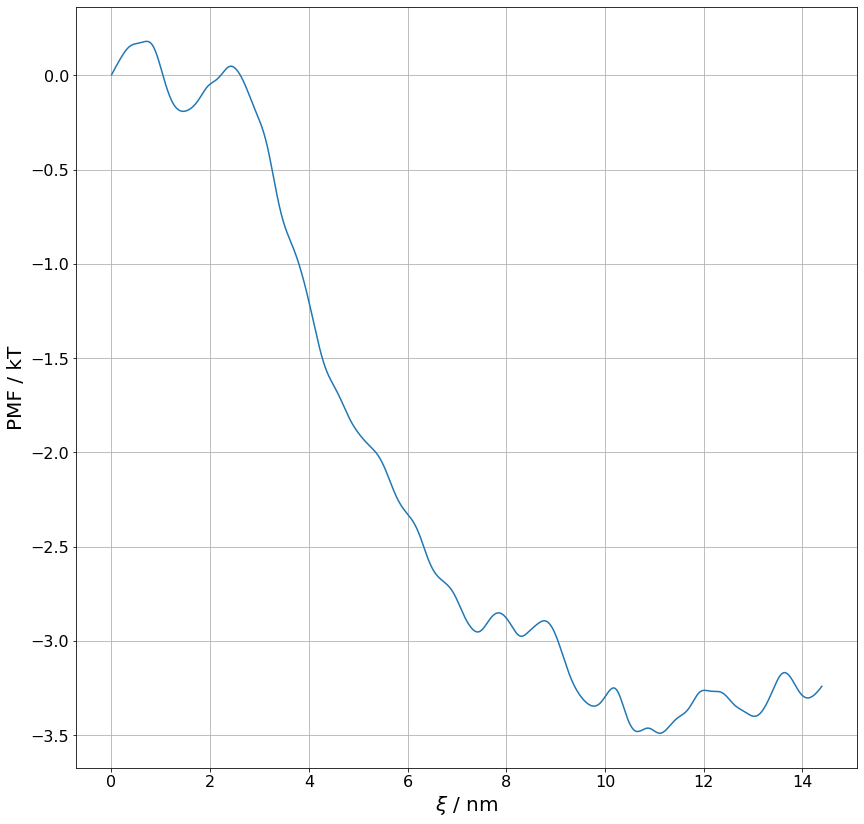

In [67]:
plt.plot(xi_bins_center, pmf_xi, color='C0')

plt.xlabel(r'$\xi$ / nm')
plt.ylabel('PMF / kT')
plt.grid()

plt.show()

In [68]:
#s_edges = np.linspace(0.25,0.5, 2001)
s_edges = np.linspace(0.0,0.5, 2001)
s_center_bins = s_edges[:-1] + (s_edges[1] - s_edges[0]) / 2
s_center_bins

array([1.25000e-04, 3.75000e-04, 6.25000e-04, ..., 4.99375e-01,
       4.99625e-01, 4.99875e-01])

In [69]:
fitted_shape_coeff_bins = outsideshaper.get_FCoeff(g_mean, Lx, s=s_center_bins)

curv_bins = calc_curvature(fitted_shape_coeff_bins)
dKds_bins = calc_dKds(fitted_shape_coeff_bins)

In [70]:
pmf_s = pmf_xi + np.log(np.abs(1 / (np.abs(1 + curv_bins * d) * L_hat)))
pmf_K = pmf_xi + np.log(np.abs(1 / (np.abs(1 + curv_bins * d) * L_hat) * dKds_bins))

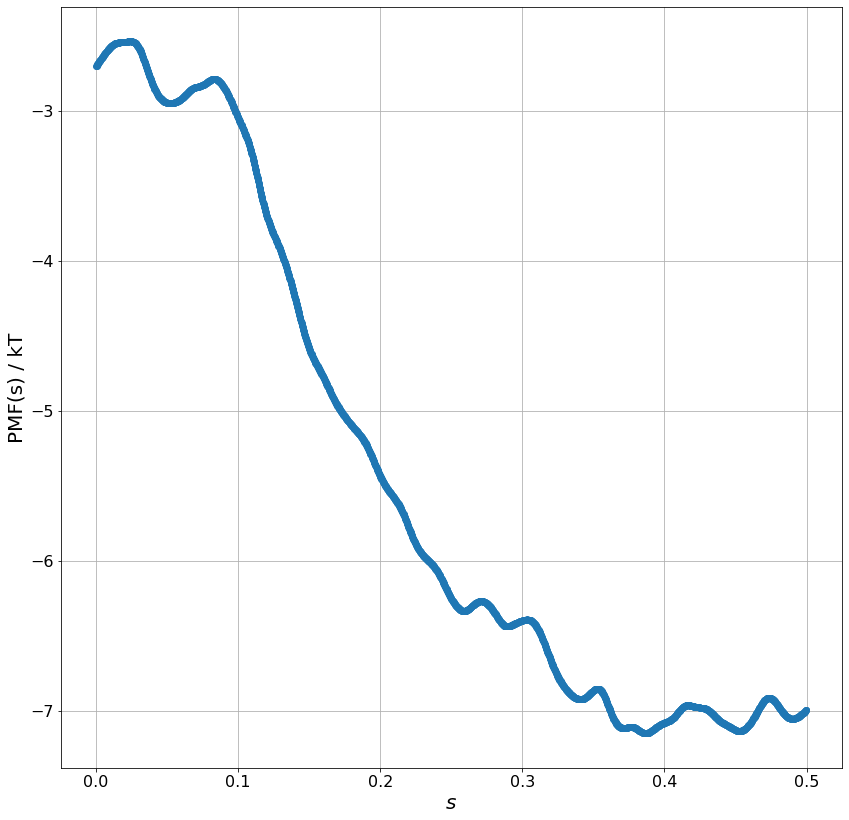

In [71]:
plt.plot(s_center_bins, pmf_s, 'o')

plt.grid()

plt.xlabel(r'$s$')
plt.ylabel(r'PMF(s) / kT')

plt.show()

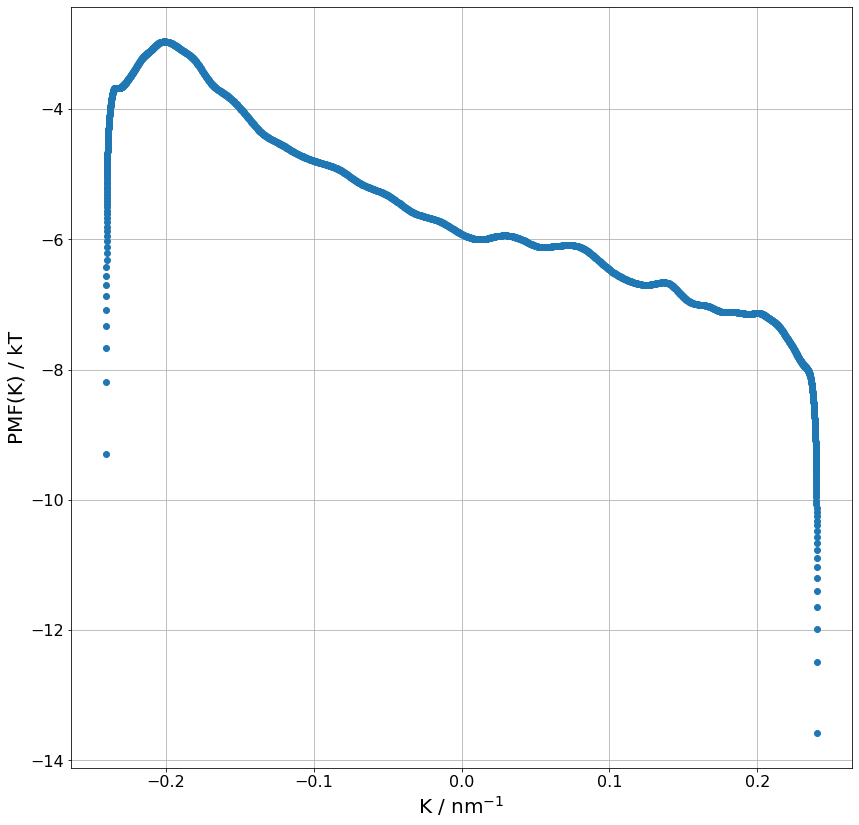

In [72]:
plt.plot(curv_bins, pmf_K, 'o')

plt.grid()

plt.xlabel(r'K / nm$^{-1}$')
plt.ylabel(r'PMF(K) / kT')

plt.show()

In [73]:
def smooth(x,n):

    # ensure n is odd
    if (n % 2) == 0:
        n += 1

    # calculate wing size
    wing_size = int((n-1)/2)

    # initiate x_smooth (no need to change first and last value)
    x_smooth = x.copy() # brackets ensures list x is not edited
    #x_smooth = x_smooth.astype(float)
    j = 1
    rest = len(x)-j
    while j < len(x)-1:
        if (j < wing_size) or (rest-1 < wing_size) > j:
            i_max = j
        elif rest-1 < wing_size:
            i_max = rest-1
        else:
            i_max = wing_size
        sum = x[j]
        for i in range(1,i_max+1):
            sum += x[j-i] + x[j+i]
        x_smooth[j] = sum/(2*i_max+1)
        j += 1
        rest = len(x) - j

    return x_smooth

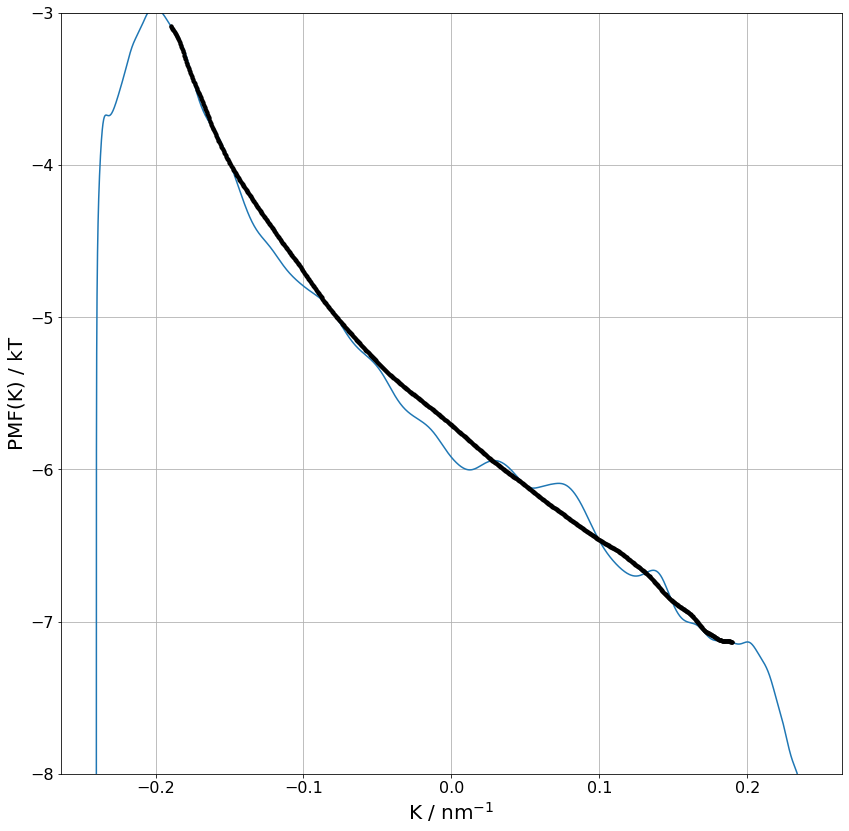

In [83]:
from scipy.optimize import curve_fit
xmin,xmax = -0.19,0.19
idx = np.where((curv_bins<xmax) & (curv_bins > xmin))
#print(idx)
n=600
xnew = curv_bins[idx]
ynew = pmf_K[idx]

yav = smooth(pmf_K[idx],n)

with open('pmf.dat','w') as f:
    for (xi,yi) in zip(xnew,yav):
        f.write('%f    %f\n' % (xi,yi))
                
def func(x,a,b,c):
    y = a*(x-b)**2+c
    return y

popt,pcov = curve_fit(func,xnew,ynew,p0=[1,0.2,-10])
fit = func(xnew,*popt)

plt.plot(curv_bins,pmf_K)
plt.plot(xnew, yav, '.',color='black')
#plt.plot(xnew,fit,color='red')

plt.grid()

plt.xlabel(r'K / nm$^{-1}$')
plt.ylabel(r'PMF(K) / kT')
#plt.xlim(-0.2,0.2)
plt.ylim(-8,-3)
plt.show()